In [51]:
library(dplyr)
library(readr)
library(stringr)
library(purrr)

resdir <- "/nfs/team292/projects/PanTissue/results/freeze/ATAC/benchmark"

# List all matching files
files <- list.files(
  resdir,
  pattern = "^ENCODE_enrichment_.+\\.csv$",
  full.names = TRUE
)

# Parse filename metadata and read each file
parse_and_read <- function(filepath) {
  fname <- basename(filepath)
  
  # Remove prefix and suffix
  core <- str_remove(fname, "^ENCODE_enrichment_") |>
    str_remove("\\.csv$")
  
  # Detect intergenic
  intergenic <- str_detect(core, "_intergenic$")
  core <- str_remove(core, "_intergenic$")
  
  # Last token is peak_type (allpeaks or linkedpeaks)
  peak_type <- str_extract(core, "(allpeaks|linkedpeaks)$")
  annotation <- str_remove(core, paste0("_", peak_type, "$"))
  
  read_csv(filepath, show_col_types = FALSE) |>
    select(-1) |>  # drop row-number column
    mutate(
      annotation  = annotation,
      peak_type   = peak_type,
      intergenic  = intergenic,
      .before = 1
    )
}

results <- map(files, parse_and_read) |> list_rbind()

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [52]:
library(qvalue)

In [53]:
results$qval=p.adjust(results$pval,method="BH")

In [54]:
head(results)

annotation,intergenic,category,peak_type,observed,expected,exp_sd,enrichment,se,zscore,pval,qval
<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CA,TRUE,CA,allpeaks,12977,12944.366,114.92644,1.0025211,0.008878491,0.2840,0.402597403,0.415584416
CA,FALSE,CA,allpeaks,28605,43402.577,199.05866,0.6590622,0.004586333,-74.3378,0.000999001,0.001102346
CA,TRUE,CA,linkedpeaks,1549,2758.964,51.66378,0.5614426,0.018725789,-23.4200,0.000999001,0.001102346
CA,FALSE,CA,linkedpeaks,3696,10058.682,101.82328,0.3674438,0.010122925,-62.4875,0.000999001,0.001102346
CA-CTCF,TRUE,CA-CTCF,allpeaks,9623,5922.901,75.00530,1.6247106,0.012663609,49.3312,0.000999001,0.001102346
CA-CTCF,FALSE,CA-CTCF,allpeaks,20888,19847.527,138.09543,1.0524233,0.006957815,7.5344,0.000999001,0.001102346


In [8]:
library(dplyr)
library(ggplot2)
library(forcats)


# ── Build plot aesthetics ──────────────────────────────────────────────────────
# Colour = peak_type (allpeaks=blue, linkedpeaks=red)
# Shade  = intergenic (FALSE=saturated, TRUE=desaturated/light)

colour_map <- c(
  "allpeaks_FALSE"    = "#2166ac",   # deep blue
  "allpeaks_TRUE"     = "#92c5de",   # light blue
  "linkedpeaks_FALSE" = "#d6604d",   # deep red
  "linkedpeaks_TRUE"  = "#f4a582"    # light red/salmon
)

results_plot <- results |>
  mutate(
    group = paste0(peak_type, "_", intergenic),
    # 95% CI from SE (z = 1.96)
    ci_lo = enrichment - 1.96 * se,
    ci_hi = enrichment + 1.96 * se,
    # Readable label for legend
    group_label = case_when(
      group == "allpeaks_FALSE"    ~ "allpeaks",
      group == "allpeaks_TRUE"     ~ "allpeaks (intergenic)",
      group == "linkedpeaks_FALSE" ~ "linkedpeaks",
      group == "linkedpeaks_TRUE"  ~ "linkedpeaks (intergenic)"
    ),
    group_label = factor(group_label, levels = c(
      "allpeaks", "allpeaks (intergenic)",
      "linkedpeaks", "linkedpeaks (intergenic)"
    )),
    # Order categories by median enrichment for readability
    category = fct_reorder(category, enrichment, .fun = median)
  )

# Dodge width so groups don't overlap per category
dodge <- position_dodge(width = 0.6)

p <- ggplot(results_plot, aes(
    x      = enrichment,
    y      = category,
    colour = group_label,
    shape  = group_label
  )) +
  # Reference line at enrichment = 1
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  # CI whiskers
  geom_linerange(
    aes(xmin = ci_lo, xmax = ci_hi),
    position = dodge, linewidth = 0.5, alpha = 0.8
  ) +
  # Point estimates
  geom_point(
    position = dodge, size = 2.5
  ) +
  scale_colour_manual(
    values = c(
      "allpeaks"              = "#2166ac",
      "allpeaks (intergenic)" = "#92c5de",
      "linkedpeaks"           = "#d6604d",
      "linkedpeaks (intergenic)" = "#f4a582"
    ),
    name = NULL
  ) +
  scale_shape_manual(
    values = c(
      "allpeaks"              = 16,
      "allpeaks (intergenic)" = 1,   # open circle = intergenic
      "linkedpeaks"           = 15,
      "linkedpeaks (intergenic)" = 0 # open square = intergenic
    ),
    name = NULL
  ) +
  labs(
    x     = "Enrichment (± 95% CI)",
    y     = NULL,
    title = "ENCODE annotation enrichment"
  ) +
  theme_bw(base_size = 11) +
  theme(
    panel.grid.major.y = element_line(colour = "grey92"),
    panel.grid.major.x = element_line(colour = "grey92"),
    panel.grid.minor   = element_blank(),
    legend.position    = "bottom",
    legend.key.size    = unit(0.9, "lines"),
    plot.title         = element_text(face = "bold", size = 13)
  )

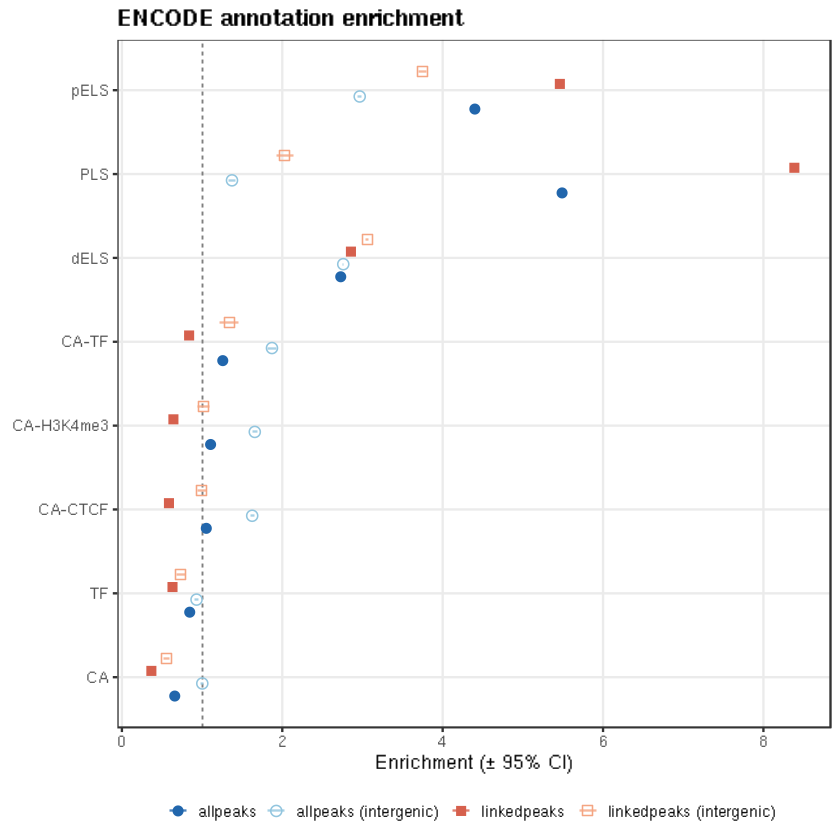

In [9]:
p

In [55]:

# ── Filter to allpeaks only ────────────────────────────────────────────────────
plot_df <- results |>
  filter(peak_type == "allpeaks") |>
  mutate(
    ci_lo = enrichment - 1 - 1.96 * se,
    ci_hi = enrichment -1 + 1.96 * se,
    # intergenic as factor: FALSE on top, TRUE below (dodge order)
    intergenic = factor(intergenic, levels = c(FALSE, TRUE),
                        labels = c("All peaks", "Intergenic peaks")),
    # order categories by allpeaks (non-intergenic) enrichment
    category = fct_reorder(
      category,
      ifelse(intergenic == "All peaks", enrichment, NA),
      .fun = function(x) mean(x, na.rm = TRUE)
    )
  )

# Colours: saturated for all peaks, lighter tint for intergenic
col_all        <- "#2166ac"
col_intergenic <- "#92c5de"

p <- ggplot(plot_df, aes(
    y        = category,
    x        = enrichment,
    fill     = intergenic,
    colour   = intergenic
  )) +
  # Reference line at 1
  geom_vline(xintercept = 0, linetype = "dashed",
             colour = "grey50", linewidth = 0.4) +
  # Bars from y-axis (xmin = 1 so they originate at the null)
  geom_col(
    aes(x = enrichment - 1),   # geom_col needs width from 0; we shift below
    position = position_dodge(width = 0.7),
    width = 0.6,
    orientation = "y"
  ) +
  # Error bars
  geom_errorbarh(
    aes(xmin = ci_lo, xmax = ci_hi),
    position = position_dodge(width = 0.7),
    height = 0.25, linewidth = 0.5, color='black'
  ) +
  scale_fill_manual(
    values = c("All peaks" = col_all, "Intergenic peaks" = col_intergenic),
    name = NULL
  ) +
  scale_colour_manual(
    values = c("All peaks" = col_all, "Intergenic peaks" = col_intergenic),
    name = NULL
  ) +
  coord_cartesian(xlim = c(-1, 5)) +
  scale_x_continuous(
    labels = function(x) x + 1,
    expand = expansion(mult = c(0, 0.05))
  ) +
  labs(
    x     = "Enrichment",
    y     = "ENCODE annotation",
  ) +
  theme_classic() +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.major.x = element_line(colour = "grey92"),
    panel.grid.minor   = element_blank(),
    legend.position    = "bottom",
    plot.title         = element_text(face = "bold", size = 13)
  )


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `category = fct_reorder(...)`.
Caused by warning:
! `fct_reorder()` removing 16 missing values.
ℹ Use `.na_rm = TRUE` to silence this message.
ℹ Use `.na_rm = FALSE` to preserve NAs.”


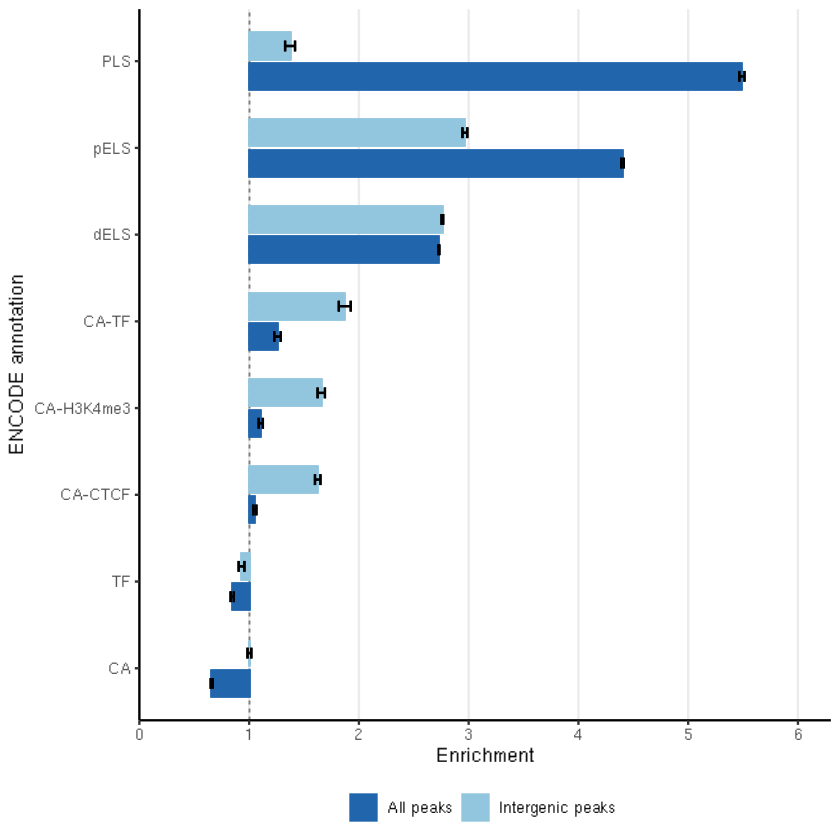

In [56]:
p

In [12]:
resdir

[1] "/nfs/team292/projects/PanTissue/results/freeze/ATAC/benchmark"

In [46]:
write_csv(results, file.path(resdir, "ENCODE_enrichment_combined.csv"))

In [57]:

ggsave(
  file.path("/nfs/team292/projects/PanTissue/results/freeze/ATAC/plots/ENCODE_enrichment_barplot.pdf"),
  p,
  width  = 3.5,
  height = 3,
)

In [42]:
results

annotation,intergenic,category,peak_type,observed,expected,exp_sd,enrichment,se,zscore,pval,qval
<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CA,TRUE,CA,allpeaks,12977,12944.366,114.92644,1.0025211,0.008878491,0.2840,0.402597403,0.415584416
CA,FALSE,CA,allpeaks,28605,43402.577,199.05866,0.6590622,0.004586333,-74.3378,0.000999001,0.001102346
CA,TRUE,CA,linkedpeaks,1549,2758.964,51.66378,0.5614426,0.018725789,-23.4200,0.000999001,0.001102346
CA,FALSE,CA,linkedpeaks,3696,10058.682,101.82328,0.3674438,0.010122925,-62.4875,0.000999001,0.001102346
CA-CTCF,TRUE,CA-CTCF,allpeaks,9623,5922.901,75.00530,1.6247106,0.012663609,49.3312,0.000999001,0.001102346
CA-CTCF,FALSE,CA-CTCF,allpeaks,20888,19847.527,138.09543,1.0524233,0.006957815,7.5344,0.000999001,0.001102346
CA-CTCF,TRUE,CA-CTCF,linkedpeaks,1260,1264.556,34.38263,0.9963972,0.027189485,-0.1325,0.445554446,0.445554446
CA-CTCF,FALSE,CA-CTCF,linkedpeaks,2699,4600.556,66.44101,0.5866682,0.014441951,-28.6202,0.000999001,0.001102346
CA-H3K4me3,TRUE,CA-H3K4me3,allpeaks,5621,3392.196,57.67559,1.6570387,0.017002435,38.6438,0.000999001,0.001102346
